In [1]:
import os
import sys
sys.path.insert(0,os.path.abspath('../src/'))

In [2]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import numpy as np
import xarray as xr

import matplotlib.pyplot as plt

from topo_edit_util import map_mask, mom6_latlon2ij, map_maskij


In [3]:
path_old = '/glade/work/bryan/MOM6-data-files/Topography/tx2_3v2/'
file_old = 'topo.sub150.tx2_3v2.srtm.edit4.SmL1.0_C1.0.nc'
df_old = xr.open_dataset(path_old+file_old)

In [4]:
path_new = '/glade/work/bryan/tx2_3v3_Feb2026/'
file_new = 'topo.sub150.tx2_3v3.SRTM15_V2.4.edit1.nc'
df_new = xr.open_dataset(path_new+file_new)

In [5]:
df_new

<xarray.Dataset> Size: 19MB
Dimensions:     (lath: 480, lonh: 540, latq: 481, lonq: 541)
Coordinates:
  * lath        (lath) float64 4kB -81.56 -81.46 -81.36 ... 89.33 89.6 89.86
  * lonh        (lonh) float64 4kB -286.7 -286.0 -285.3 ... 71.33 72.0 72.67
  * latq        (latq) float64 4kB -81.61 -81.51 -81.41 ... 89.46 89.72 89.91
  * lonq        (lonq) float64 4kB -287.0 -286.3 -285.7 ... 71.67 72.33 73.0
Data variables: (12/14)
    geolon      (lath, lonh) float64 2MB ...
    geolat      (lath, lonh) float64 2MB ...
    geolonb     (latq, lonq) float64 2MB ...
    geolatb     (latq, lonq) float64 2MB ...
    z           (lath, lonh) float32 1MB ...
    ocn_frac    (lath, lonh) float32 1MB ...
    ...          ...
    D_median    (lath, lonh) float32 1MB ...
    D2_mean     (lath, lonh) float32 1MB ...
    D_min       (lath, lonh) float32 1MB ...
    D_max       (lath, lonh) float32 1MB ...
    hand_edits  (lath, lonh) int32 1MB ...
    orig_mask   (lath, lonh) int32 1MB ...
Attributes:
    Description:             Ocean Topography Statistics on MOM6 Grid
    Creator:                 Frank Bryan
    Created:                 20260225
    Generating Code:         create_model_topo.f90
    Model Grid Version:      tx2_3v3
    Source Topography Data:  /glade/work/bryan/Observations/Topography/SRTM/S...
    Edit History:            Hand Edit + Lake Fill 02/26/2026

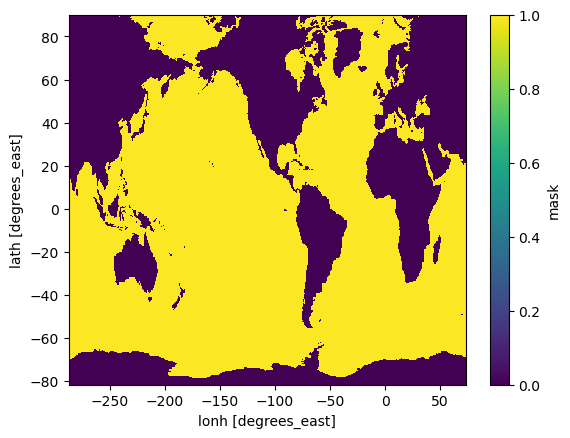

In [6]:
df_new['mask'].plot()

In [7]:
jpnt = np.array([
27,
32,
33,
33,
33,
37,
39,
39,
39,
45,
50,
51,
56,
56,
57,
58,
62,
62,
62,
63,
63,
77,
78,
78,
86,
87,
87,
88,
89,
438,
458,
])

In [8]:
ipnt = np.array([
183,
138,
138,
140,
141,
202,
135,
204,
205,
391,
136,
278,
139,
258,
140,
240,
320,
321,
322,
321,
322,
489,
489,
490,
503,
503,
504,
506,
25,
397,
383,
])

In [9]:
print('# values = ',len(ipnt))
print(" 1=Ocean   0=Land")
print(" n   i    j    Old  NEW  CHANGED")
for n in range(len(ipnt)):
    j = jpnt[n]-1
    i = ipnt[n]-1
    print(f"{n+1:3d} {j+1:4d} {i+1:4d} {df_old['mask'][j,i].values:3d} {df_new['mask'][j,i].values:3d}   {(df_old['mask'][j,i] != df_new['mask'][j,i]).values}"
          )

# values =  31
 1=Ocean   0=Land
 n   i    j    Old  NEW  CHANGED
  1   27  183   1   0   True
  2   32  138   1   0   True
  3   33  138   1   1   False
  4   33  140   1   1   False
  5   33  141   1   0   True
  6   37  202   1   0   True
  7   39  135   1   0   True
  8   39  204   1   1   False
  9   39  205   1   0   True
 10   45  391   1   0   True
 11   50  136   1   0   True
 12   51  278   1   1   False
 13   56  139   1   0   True
 14   56  258   1   0   True
 15   57  140   1   0   True
 16   58  240   1   0   True
 17   62  320   1   1   False
 18   62  321   1   1   False
 19   62  322   1   0   True
 20   63  321   1   1   False
 21   63  322   1   0   True
 22   77  489   1   0   True
 23   78  489   1   1   False
 24   78  490   1   1   False
 25   86  503   1   0   True
 26   87  503   1   1   False
 27   87  504   1   0   True
 28   88  506   1   0   True
 29   89   25   1   0   True
 30  438  397   1   0   True
 31  458  383   1   0   True


### Check Points with Ian's Modified Runoff Map

Text(139, 56, 'X')

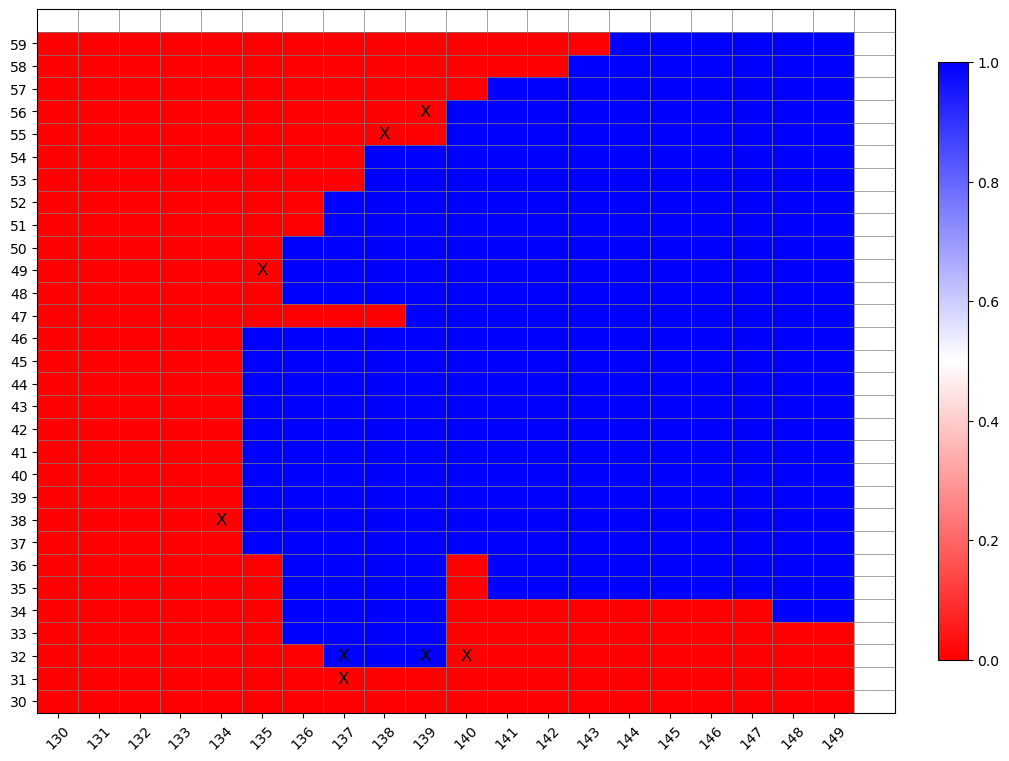

In [10]:
imin=130
imax=150
jmin=30
jmax=60
ax=map_maskij(df_new,'mask',imin,imax,jmin,jmax,
               label_skip=-1,line_skip=1,draw_coastline=False)

ax.text(137,31,'X',ha='center',va='center',fontsize=12)
ax.text(137,32,'X',ha='center',va='center',fontsize=12)
ax.text(139,32,'X',ha='center',va='center',fontsize=12)
ax.text(140,32,'X',ha='center',va='center',fontsize=12)
ax.text(134,38,'X',ha='center',va='center',fontsize=12)
ax.text(135,49,'X',ha='center',va='center',fontsize=12)
ax.text(138,55,'X',ha='center',va='center',fontsize=12)
ax.text(139,56,'X',ha='center',va='center',fontsize=12)

Text(182, 26, 'X')

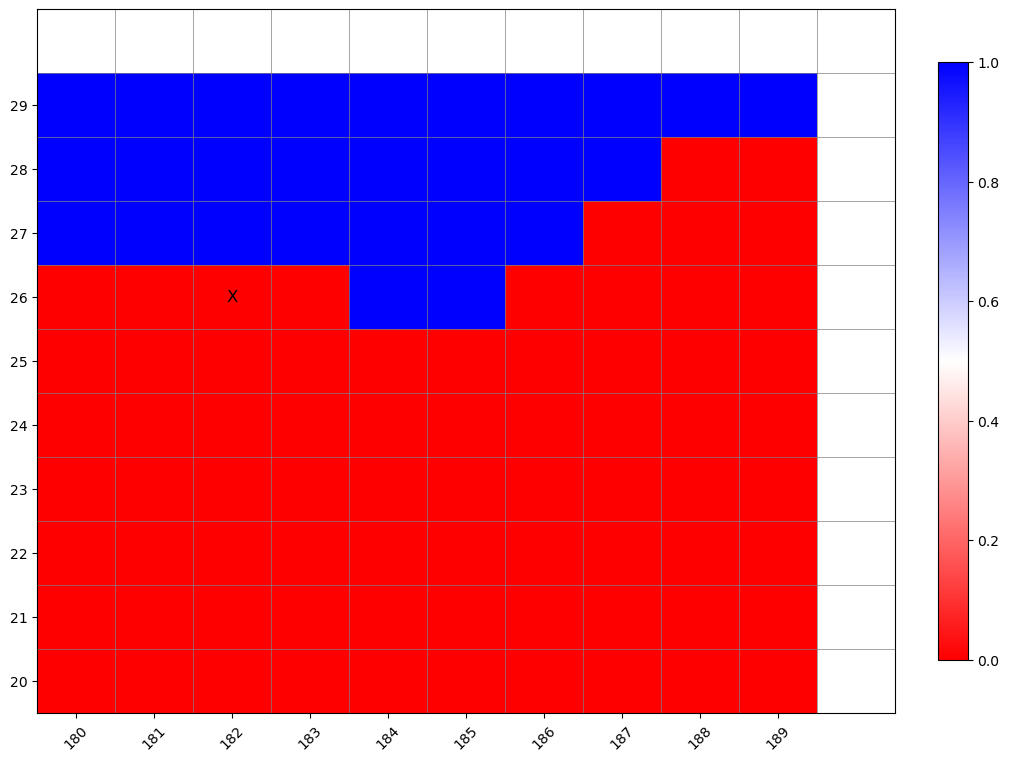

In [11]:
imin=180
imax=190
jmin=20
jmax=30
ax=map_maskij(df_new,'mask',imin,imax,jmin,jmax,
               label_skip=-1,line_skip=1,draw_coastline=False)

ax.text(182,26,'X',ha='center',va='center',fontsize=12)


Text(204, 38, 'X')

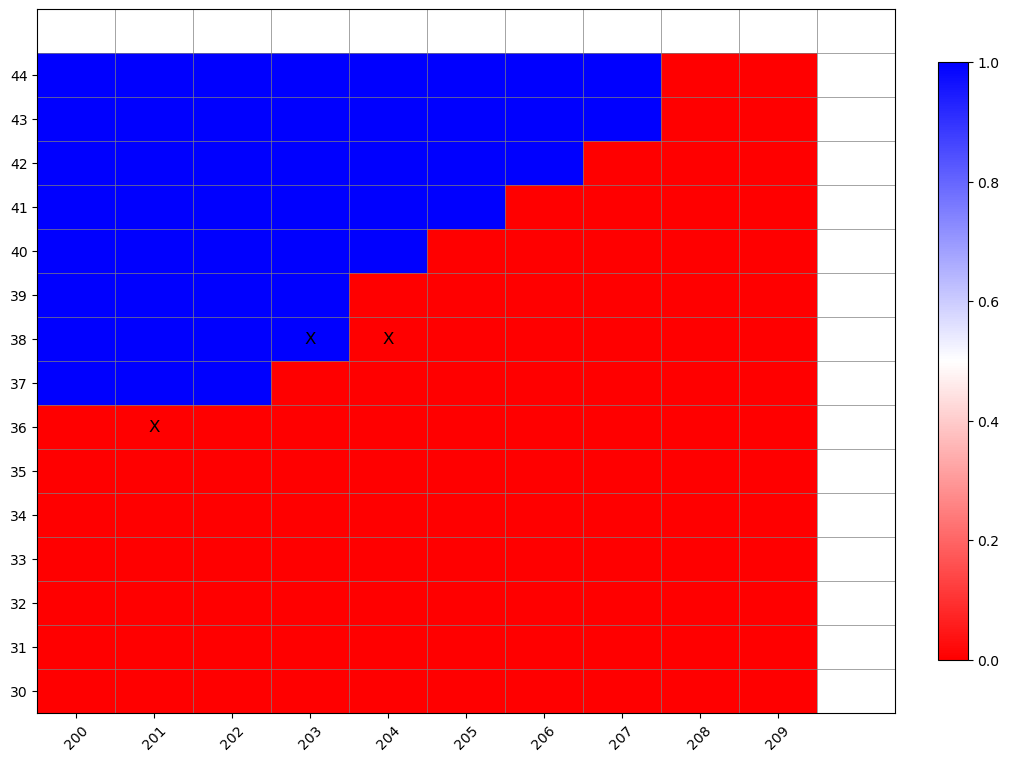

In [12]:
imin=200
imax=210
jmin=30
jmax=45
ax=map_maskij(df_new,'mask',imin,imax,jmin,jmax,
               label_skip=-1,line_skip=1,draw_coastline=False)

ax.text(201,36,'X',ha='center',va='center',fontsize=12)
ax.text(203,38,'X',ha='center',va='center',fontsize=12)
ax.text(204,38,'X',ha='center',va='center',fontsize=12)


Text(239, 57, 'X')

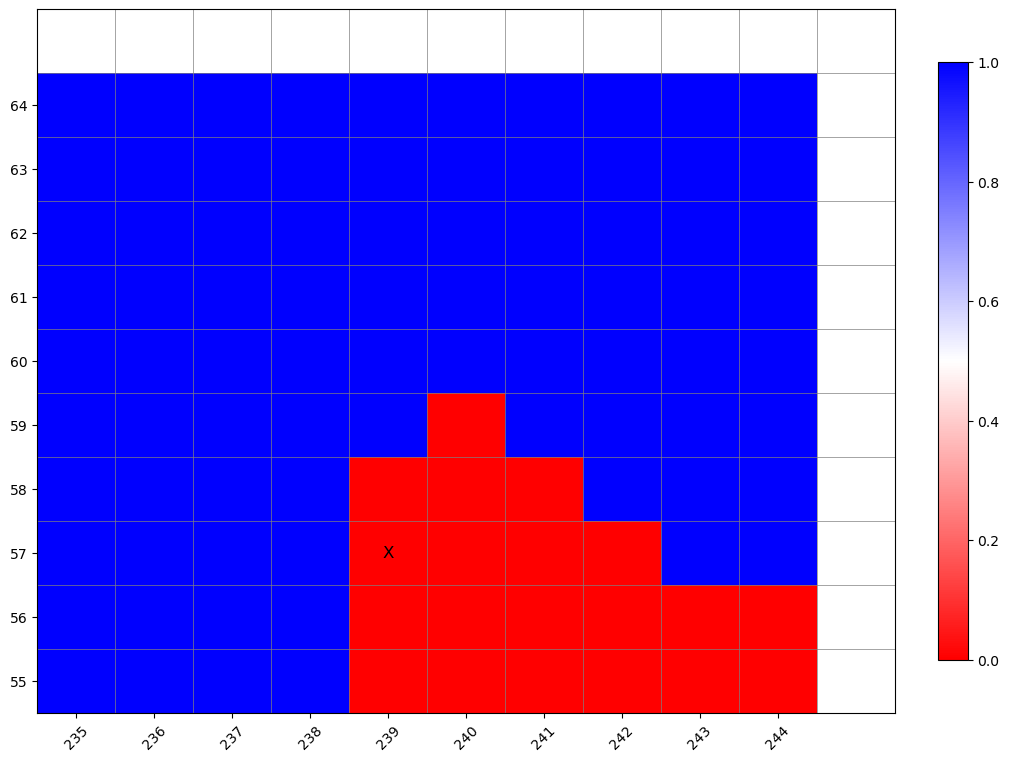

In [13]:
imin=235
imax=245
jmin=55
jmax=65
ax=map_maskij(df_new,'mask',imin,imax,jmin,jmax,
               label_skip=-1,line_skip=1,draw_coastline=False)

ax.text(239,57,'X',ha='center',va='center',fontsize=12)


Text(257, 55, 'X')

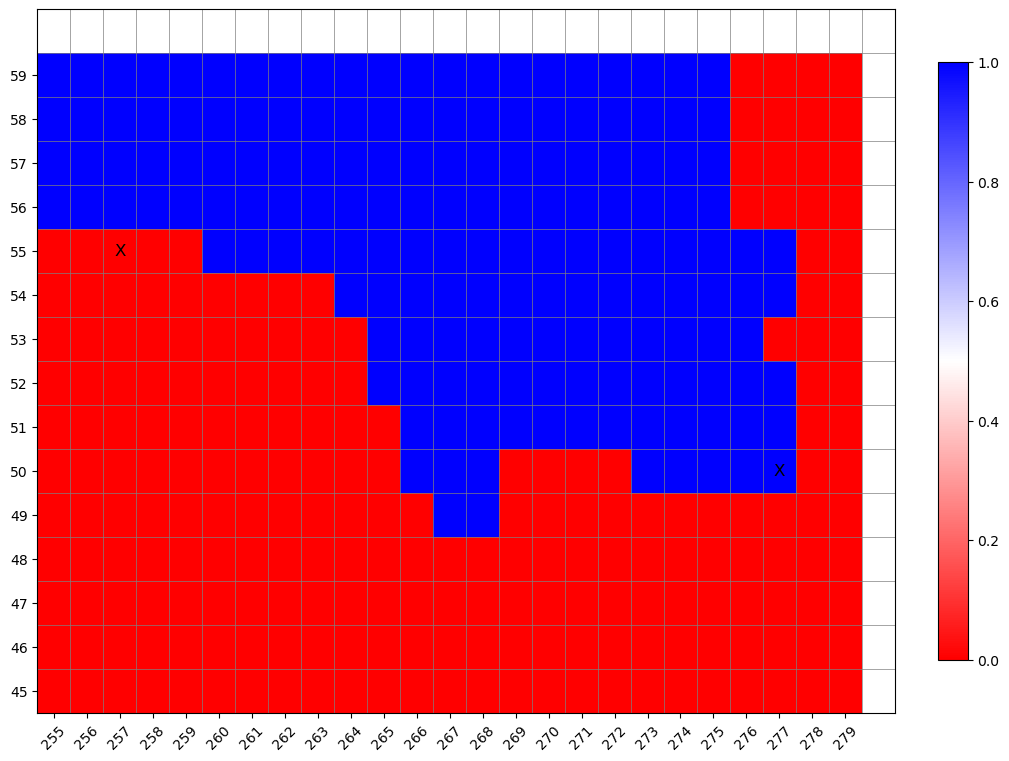

In [14]:
imin=255
imax=280
jmin=45
jmax=60
ax=map_maskij(df_new,'mask',imin,imax,jmin,jmax,
               label_skip=-1,line_skip=1,draw_coastline=False)

ax.text(277,50,'X',ha='center',va='center',fontsize=12)
ax.text(257,55,'X',ha='center',va='center',fontsize=12)


Text(321, 62, 'X')

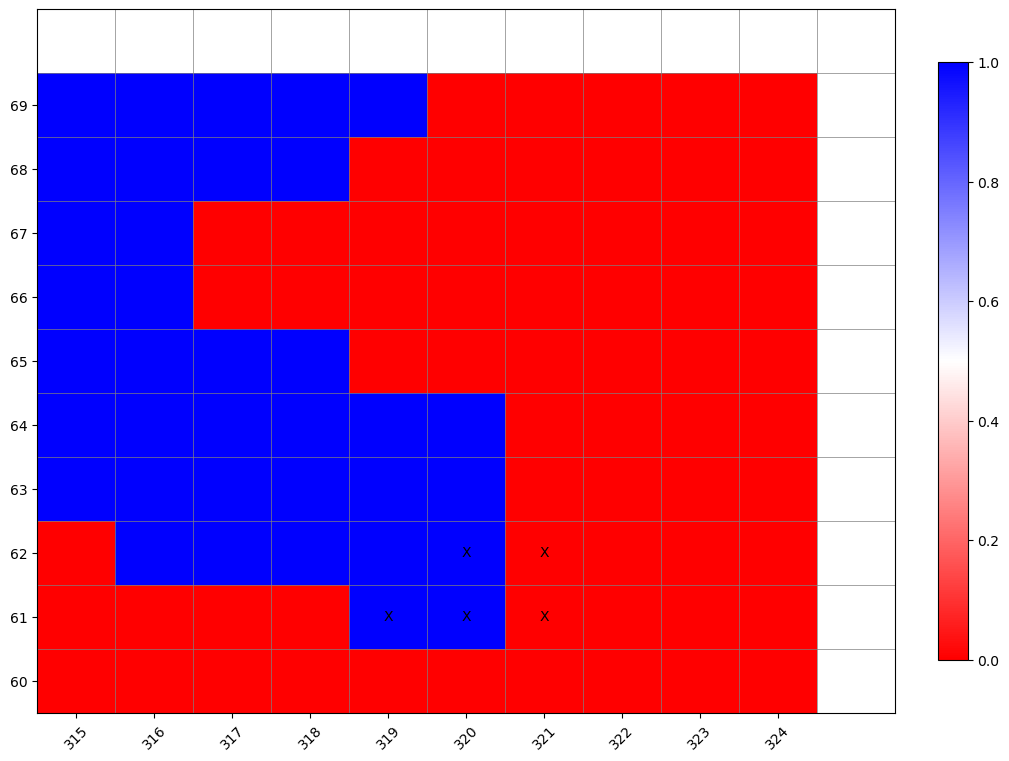

In [15]:
imin=315
imax=325
jmin=60
jmax=70
ax=map_maskij(df_new,'mask',imin,imax,jmin,jmax,
               label_skip=-1,line_skip=1,draw_coastline=False)

ax.text(319,61,'X',ha='center',va='center',fontsize=10)
ax.text(320,61,'X',ha='center',va='center',fontsize=10)
ax.text(321,61,'X',ha='center',va='center',fontsize=10)
ax.text(320,62,'X',ha='center',va='center',fontsize=10)
ax.text(321,62,'X',ha='center',va='center',fontsize=10)


Text(489, 77, 'X')

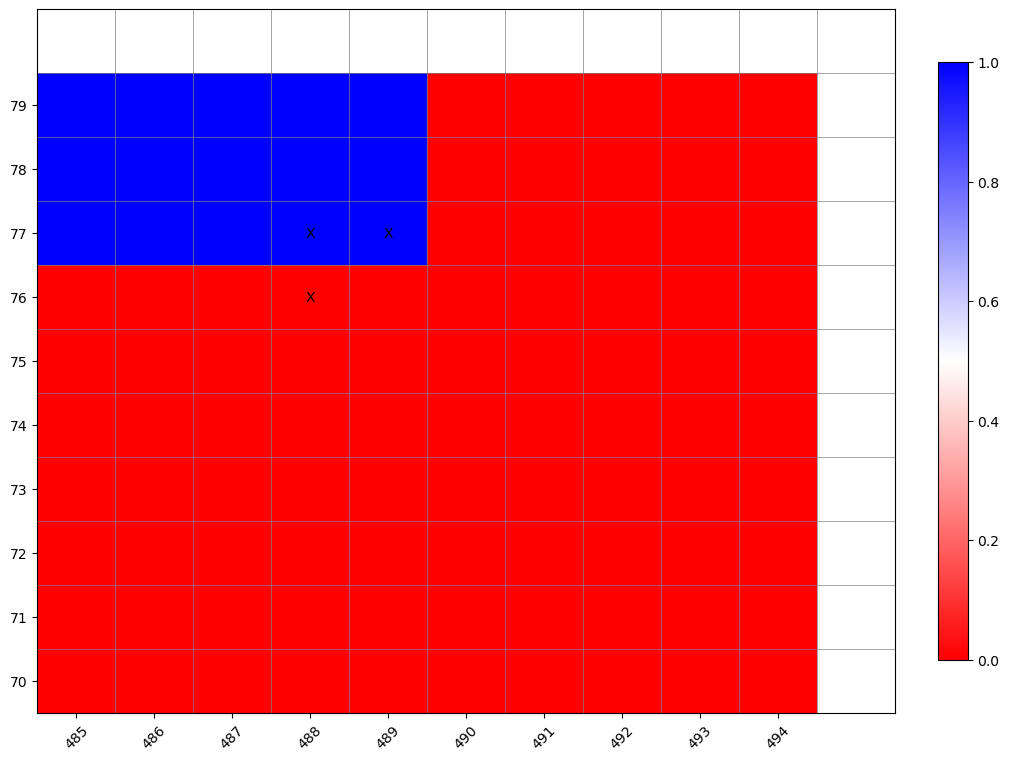

In [16]:
imin=485
imax=495
jmin=70
jmax=80
ax=map_maskij(df_new,'mask',imin,imax,jmin,jmax,
               label_skip=-1,line_skip=1,draw_coastline=False)

ax.text(488,76,'X',ha='center',va='center',fontsize=10)
ax.text(488,77,'X',ha='center',va='center',fontsize=10)
ax.text(489,77,'X',ha='center',va='center',fontsize=10)


Text(505, 87, 'X')

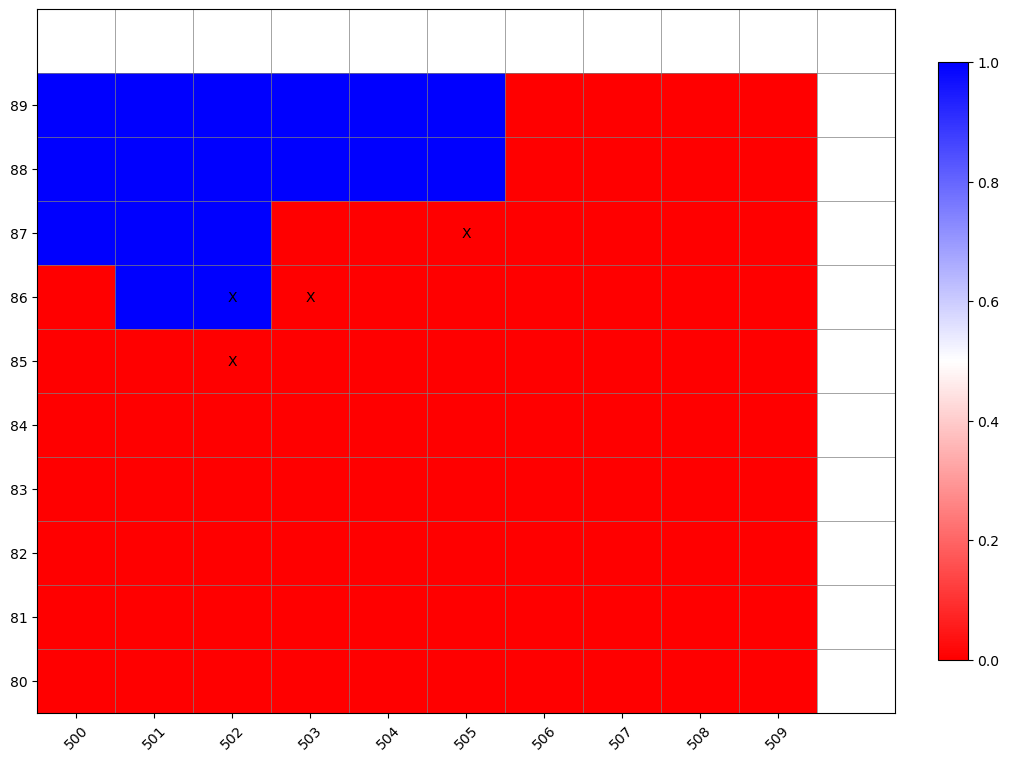

In [17]:
imin=500
imax=510
jmin=80
jmax=90
ax=map_maskij(df_new,'mask',imin,imax,jmin,jmax,
               label_skip=-1,line_skip=1,draw_coastline=False)

ax.text(502,85,'X',ha='center',va='center',fontsize=10)
ax.text(502,86,'X',ha='center',va='center',fontsize=10)
ax.text(503,86,'X',ha='center',va='center',fontsize=10)
ax.text(505,87,'X',ha='center',va='center',fontsize=10)


Text(24, 88, 'X')

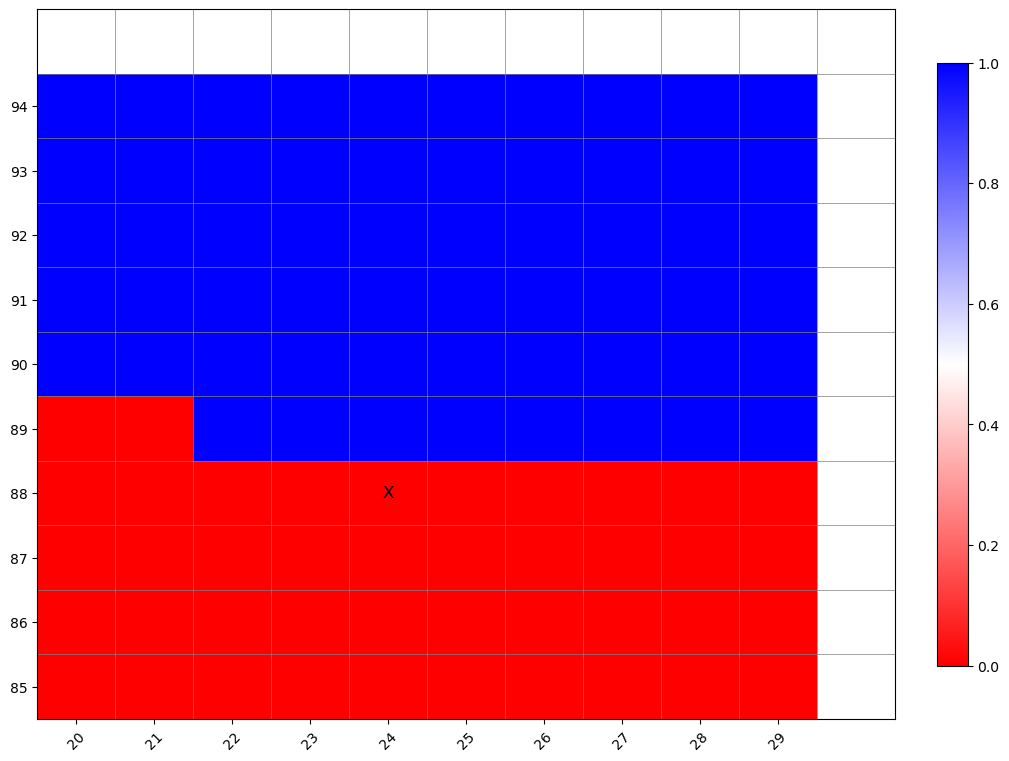

In [18]:
imin=20
imax=30
jmin=85
jmax=95
ax=map_maskij(df_new,'mask',imin,imax,jmin,jmax,
               label_skip=-1,line_skip=1,draw_coastline=False)

ax.text(24,88,'X',ha='center',va='center',fontsize=12)

Text(396, 437, 'X')

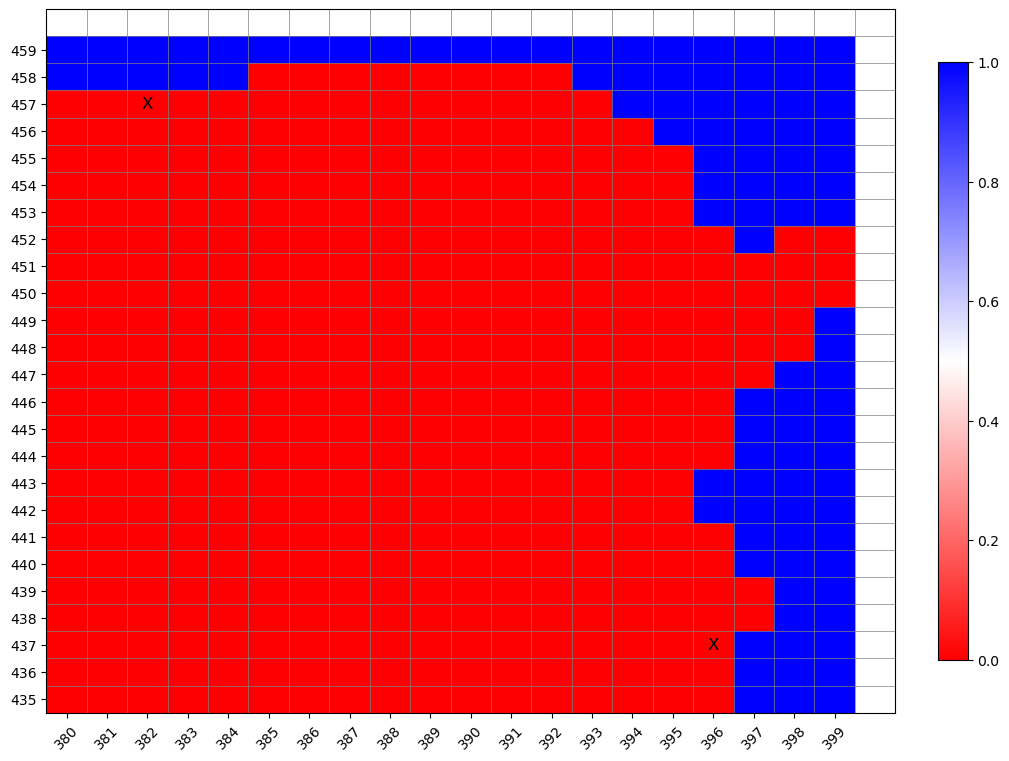

In [19]:
imin=380
imax=400
jmin=435
jmax=460
ax=map_maskij(df_new,'mask',imin,imax,jmin,jmax,
               label_skip=-1,line_skip=1,draw_coastline=False)

ax.text(382,457,'X',ha='center',va='center',fontsize=12)
ax.text(396,437,'X',ha='center',va='center',fontsize=12)